# Phân tích Khám phá Tuyển sinh Đại học Việt Nam (EDA)
## Notebook 02: Phân tích Biến động & Xu hướng Điểm chuẩn qua các năm

Notebook này thực hiện:
1. Phân tích biến động điểm chuẩn tổng thể theo năm (2020-2025).
2. So sánh giai đoạn COVID-19 (2020-2022) và Hậu COVID-19 (2023-2025).
3. Phân tích xu hướng tăng/giảm điểm chuẩn (delta_score).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/admission_processed.csv", encoding="utf-8-sig")

### 1. Biến động điểm chuẩn trung bình qua từng năm

In [2]:
avg_yearly = df.groupby('year')['admission_score'].mean().reset_index()
print(avg_yearly)

   year  admission_score
0  2020        19.862046
1  2021        20.328139
2  2022        19.351290
3  2023        19.552070
4  2024        19.695826
5  2025        19.690714


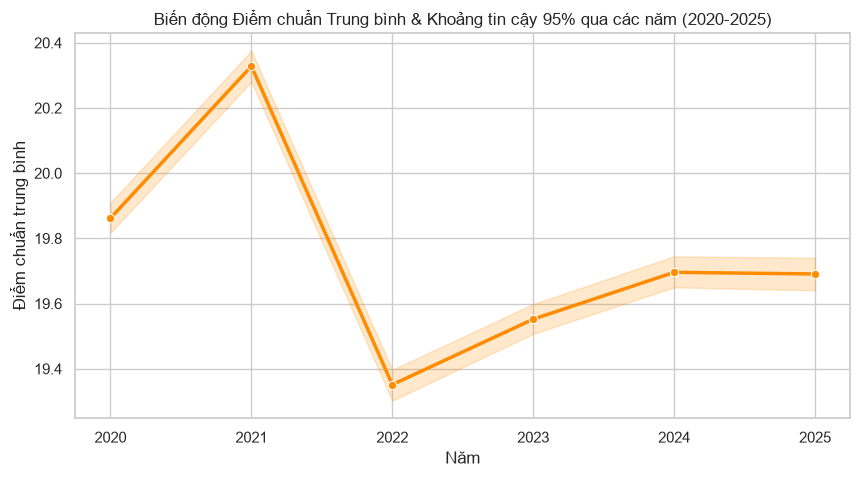

In [3]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='year', y='admission_score', data=df, marker='o', errorbar=('ci', 95), color='darkorange', linewidth=2.5)
plt.title('Biến động Điểm chuẩn Trung bình & Khoảng tin cậy 95% qua các năm (2020-2025)')
plt.xlabel('Năm')
plt.ylabel('Điểm chuẩn trung bình')
plt.show()

### 2. So sánh giai đoạn dịch bệnh COVID (2020-2022) và Hậu COVID (2023-2025)

In [4]:
# Gán nhãn giai đoạn dịch bệnh
df['period'] = df['year'].apply(lambda y: 'Trong dịch (2020-2022)' if y <= 2022 else 'Sau dịch (2023-2025)')
period_stats = df.groupby('period')['admission_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()
print(period_stats.round(2))

                   period  count   mean  median   std   min   max
0    Sau dịch (2023-2025)  93837  19.65   19.18  4.26  13.0  30.0
1  Trong dịch (2020-2022)  93837  19.85   19.40  4.24  15.0  30.0


/tmp/ipykernel_57530/2552922729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='period', y='admission_score', data=df, palette='Set2')


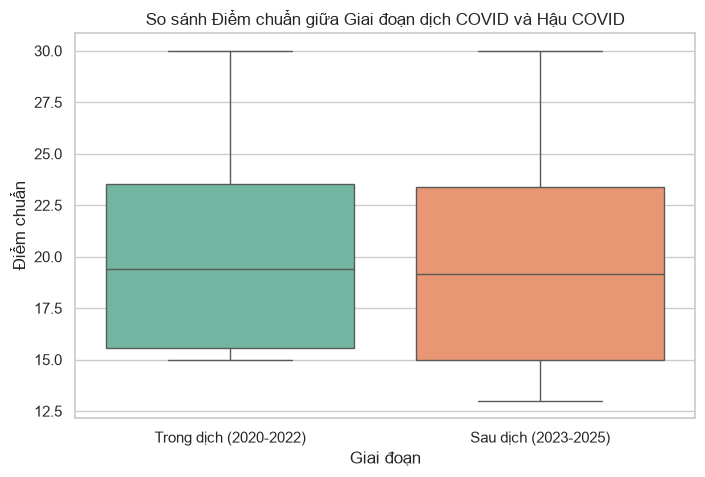

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='period', y='admission_score', data=df, palette='Set2')
plt.title('So sánh Điểm chuẩn giữa Giai đoạn dịch COVID và Hậu COVID')
plt.xlabel('Giai đoạn')
plt.ylabel('Điểm chuẩn')
plt.show()

### 3. Phân tích chênh lệch điểm chuẩn hàng năm (delta_score)

In [6]:
df_delta = df.dropna(subset=['delta_score'])
df_delta['delta_score'].describe()

count    156395.000000
mean         -0.034266
std           0.543388
min          -2.000000
25%          -0.060000
50%           0.070000
75%           0.310000
max           0.900000
Name: delta_score, dtype: float64

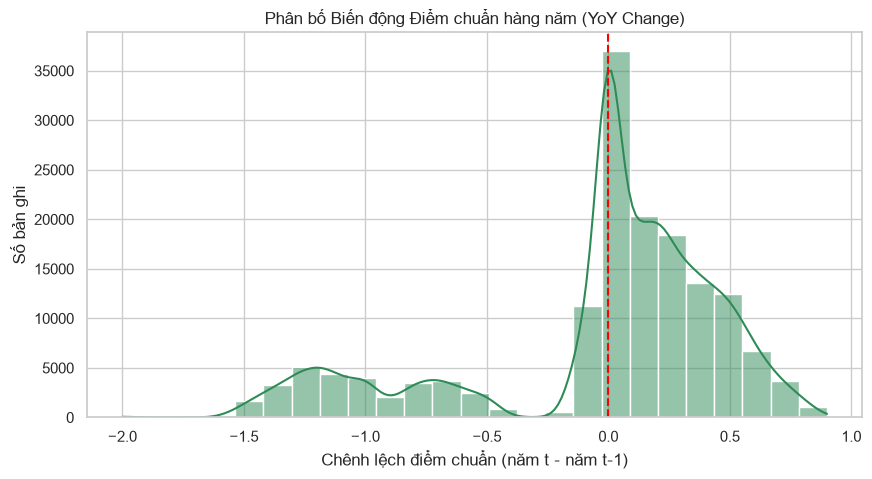

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df_delta['delta_score'], kde=True, bins=25, color='seagreen')
plt.title('Phân bố Biến động Điểm chuẩn hàng năm (YoY Change)')
plt.xlabel('Chênh lệch điểm chuẩn (năm t - năm t-1)')
plt.ylabel('Số bản ghi')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [8]:
# Tỷ lệ xu hướng tăng, giảm, ổn định
trend_counts = df['score_trend'].value_counts(dropna=False)
print("Phân bố xu hướng tuyển sinh:")
print(trend_counts)

Phân bố xu hướng tuyển sinh:
score_trend
Ổn định           108744
Không xác định     31279
Giảm               30364
Tăng               17287
Name: count, dtype: int64
